In [ ]:
### Ejercicio de Programación Lineal con Pyomo

#Se desea producir pintura verde en dos tonalidades, Verde Manzana y Verde Pino, mezclando pintura azul 
#y amarilla en distintas proporciones. Un litro de pintura Verde Manzana necesita 0.3 litros de azul 
#y 0.7 litros de amarillo, mientras que un litro (L) de pintura Verde Pino necesita 0.5 L de azul 
#y 0.5 L de amarillo. Actualmente se dispone de 20 L de pintura azul y 28 L de pintura amarilla. 
#El beneficio por litro de la pintura Verde Manzana es de 1€, y por litro de pintura Verde Pino
#es de 1.20€. No se pueden producir más de 30 L de pintura Verde Manzana. ¿Cuántos litros de pintura 
#Verde Manzana y Verde Pino debe producir para maximizar sus beneficios? ¿Cuál será el beneficio obtenido? 
#Utilice Pyomo para resolver el problema


## Planteamiento del problema

Definimos las variables de decisión:

- $x_1$: litros de pintura Verde Manzana que se van a producir para maximizar sus beneficios.
- $x_2$: litros de pintura Verde Pino que se van a producir para maximizar sus beneficios.

El objetivo es maximizar el beneficio, teniendo en cuenta que cada litro de Verde Manzana aporta 1 € y cada litro de Verde Pino aporta 1,20 €.

El modelo de programación lineal es:

$$
\begin{array}{ll}
\text{Maximizar} & Z = x_1 + 1.2x_2 \\[4pt]
\text{sujeto a} & 0.3x_1 + 0.5x_2 \leq 20 \\
& 0.7x_1 + 0.5x_2 \leq 28 \\
& x_1 \leq 30 \\
& x_1, x_2 \geq 0
\end{array}
$$

La primera restricción corresponde a la pintura azul disponible y la segunda a la pintura amarilla. La tercera limita la producción de Verde Manzana a 30 litros. Además, las cantidades producidas deben ser no negativas.

In [2]:
from pyomo.environ import *

model = ConcreteModel()

# Definimos las variables: litros de cada tipo de pintura
# Utilizamos variables reales no negativas porque los litros pueden tener decimales
model.x1 = Var(within=NonNegativeReals)
model.x2 = Var(within=NonNegativeReals)

# Definimos la función objetivo: maximizar el beneficio
model.obj = Objective(
    expr=model.x1 + 1.2 * model.x2,
    sense=maximize
)

# Restricción de pintura azul: disponemos de 20 litros
model.constraint1 = Constraint(
    expr=0.3 * model.x1 + 0.5 * model.x2 <= 20
)

# Restricción de pintura amarilla: disponemos de 28 litros
model.constraint2 = Constraint(
    expr=0.7 * model.x1 + 0.5 * model.x2 <= 28
)

# Podemos producir como máximo 30 litros de Verde Manzana
model.constraint3 = Constraint(
    expr=model.x1 <= 30
)

# Resolvemos el modelo utilizando GLPK
solver = SolverFactory("glpk")
resultado = solver.solve(model)

# Mostramos los resultados si se ha encontrado la solución óptima
if resultado.solver.termination_condition == TerminationCondition.optimal:
    print(f"Litros de Verde Manzana: {value(model.x1):.2f}")
    print(f"Litros de Verde Pino: {value(model.x2):.2f}")
    print(f"Beneficio máximo: {value(model.obj):.2f} €")
else:
    print("No se ha obtenido una solución óptima.")
    print(resultado.solver.termination_condition)

Litros de Verde Manzana: 20.00
Litros de Verde Pino: 28.00
Beneficio máximo: 53.60 €


## Interpretación de los resultados

Para maximizar el beneficio debemos producir **20 litros de Verde Manzana y 28 litros de Verde Pino**. El beneficio máximo obtenido es de **53,60 €**.

Comprobamos el consumo de pintura:

- **Azul:** $0.3 \cdot 20 + 0.5 \cdot 28 = 20$ litros.
- **Amarilla:** $0.7 \cdot 20 + 0.5 \cdot 28 = 28$ litros.

Se utiliza toda la pintura disponible de ambos colores. Además, los 20 litros de Verde Manzana no superan el límite de 30 litros.

El beneficio total es:

$$
Z = 20 + 1.2 \cdot 28 = 53.60 \text{ €}
$$

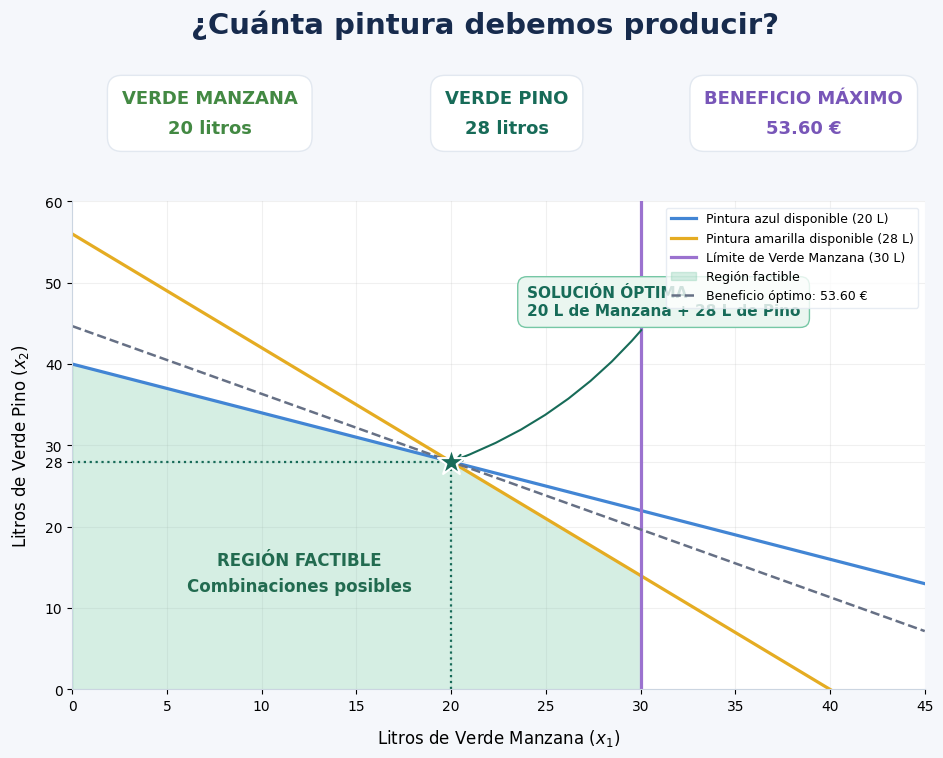

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Recogemos los resultados del modelo que ya hemos resuelto
manzana = value(model.x1)
pino = value(model.x2)
beneficio = value(model.obj)

# Definimos las rectas de las restricciones
x = np.linspace(0, 45, 600)
limite_azul = (20 - 0.3 * x) / 0.5
limite_amarilla = (28 - 0.7 * x) / 0.5

# Creamos la figura
fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor("#F5F7FB")
ax.set_facecolor("white")
fig.subplots_adjust(top=0.73, bottom=0.12)

fig.suptitle(
    "¿Cuánta pintura debemos producir?",
    fontsize=21, fontweight="bold", y=0.97, color="#172B4D"
)

# Mostramos los resultados en tres tarjetas
tarjetas = [
    (0.25, "VERDE MANZANA", f"{manzana:.0f} litros", "#438943"),
    (0.52, "VERDE PINO", f"{pino:.0f} litros", "#176B58"),
    (0.79, "BENEFICIO MÁXIMO", f"{beneficio:.2f} €", "#7856B8")
]

for posicion, titulo, dato, color in tarjetas:
    fig.text(
        posicion, 0.84, f"{titulo}\n{dato}",
        ha="center", va="center", fontsize=13,
        fontweight="bold", color=color,
        linespacing=1.8,
        bbox=dict(
            boxstyle="round,pad=0.8",
            facecolor="white", edgecolor="#E2E8F0"
        )
    )

# Dibujamos las restricciones
ax.plot(
    x, limite_azul, color="#4285D4", linewidth=2.3,
    label="Pintura azul disponible (20 L)"
)
ax.plot(
    x, limite_amarilla, color="#E5AC22", linewidth=2.3,
    label="Pintura amarilla disponible (28 L)"
)
ax.axvline(
    30, color="#9B72CF", linewidth=2.3,
    label="Límite de Verde Manzana (30 L)"
)

# Sombreamos las combinaciones que cumplen todas las restricciones
x_factible = np.linspace(0, 30, 400)
techo_factible = np.minimum(
    (20 - 0.3 * x_factible) / 0.5,
    (28 - 0.7 * x_factible) / 0.5
)

ax.fill_between(
    x_factible, 0, techo_factible,
    color="#76C7A5", alpha=0.3,
    label="Región factible"
)

ax.text(
    12, 12, "REGIÓN FACTIBLE\nCombinaciones posibles",
    ha="center", fontsize=12, color="#226B50",
    fontweight="bold", linespacing=1.6
)

# Dibujamos la recta de beneficio que pasa por la solución óptima
recta_beneficio = (beneficio - x) / 1.2
ax.plot(
    x, recta_beneficio, "--",
    color="#667085", linewidth=1.8,
    label=f"Beneficio óptimo: {beneficio:.2f} €"
)

# Añadimos líneas auxiliares para leer las cantidades en los ejes
ax.plot(
    [manzana, manzana], [0, pino],
    ":", color="#176B58", linewidth=1.6
)
ax.plot(
    [0, manzana], [pino, pino],
    ":", color="#176B58", linewidth=1.6
)

# Destacamos el punto óptimo con una estrella
ax.scatter(
    manzana, pino, s=420, marker="*",
    color="#176B58", edgecolor="white",
    linewidth=1.5, zorder=6
)

ax.annotate(
    f"SOLUCIÓN ÓPTIMA\n"
    f"{manzana:.0f} L de Manzana + {pino:.0f} L de Pino",
    xy=(manzana, pino), xytext=(24, 46),
    fontsize=11, fontweight="bold", color="#176B58",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#EAF6F0", edgecolor="#76C7A5"
    ),
    arrowprops=dict(
        arrowstyle="->", color="#176B58",
        linewidth=1.5, connectionstyle="arc3,rad=-0.15"
    )
)

# Ajustamos el aspecto de la gráfica
ax.set_xlim(0, 45)
ax.set_ylim(0, 60)
ax.set_xlabel("Litros de Verde Manzana ($x_1$)", fontsize=12, labelpad=10)
ax.set_ylabel("Litros de Verde Pino ($x_2$)", fontsize=12, labelpad=10)

ax.set_xticks(sorted(set(range(0, 46, 5)) | {round(manzana, 6)}))
ax.set_yticks(sorted(set(range(0, 61, 10)) | {round(pino, 6)}))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CBD5E1")
ax.spines["bottom"].set_color("#CBD5E1")
ax.grid(alpha=0.18)
ax.set_axisbelow(True)

ax.legend(
    loc="upper right", fontsize=9,
    frameon=True, facecolor="white", edgecolor="#E2E8F0"
)

plt.show()